In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord
from scipy import stats
import statsmodels.api as sm


In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


# Compare CSFD to SFD

## Start with SFD redMaGiC catalogs

In [4]:
###
### Traditional SFD hidens, with and without bins
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_v2/'
dk = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_compensated_signal.txt', header_start=1, format='ascii')
dr = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_bg_randoms.txt', header_start=1, format='ascii')
fr = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fg_randoms.txt', header_start=1, format='ascii')
rr = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_5zbins_WISEzcut_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_usebins = Table.read(output_path+'z_lt_0.5_dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z, guess only with z cut?
###
output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_v2/'
dk_hiz = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_WISEzcut_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_WISEzcut_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_WISEzcut_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_WISEzcut_raw_signal.txt', header_start=1, format='ascii')
rr_hiz = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_WISEzcut_fgxbg_randoms.txt', header_start=1, format='ascii')


## CSFD redMaGiC catalogs

In [28]:
###
### CSFD hidens, with and without bins plus one with a redshift cut
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_csfd/'
dk_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_usebins_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_usebins_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_usebins_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_usebins_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z CSFD
###
output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_csfd/'
dk_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_hiz_usebins_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_usebins_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_usebins_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_usebins_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_usebins_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

### Also random3, which was an alternative WISE catalog!
dk_hiz_rand3_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_randoms3_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_rand3_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_randoms3_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_rand3_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_randoms3_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_rand3_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_randoms3_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_rand3_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_randoms3_fgxbg_randoms.txt', header_start=1, format='ascii')


### Read in redMaGiC LRGs

In [6]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/lowz_hidens_fg_x_hiz_bg/'
dk_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')


## Define dust vectors

In [29]:
##
## Hi-density traditional SFD
dust_hidens = dk['kappa'] - dr['kappa'] + rr['kappa']
dust_hidens_usebins = dk_usebins['kappa'] - dr_usebins['kappa'] + rr_usebins['kappa']
##
## Hi-density CSFD incl zcut
dust_hidens_csfd = dk_csfd['kappa'] - dr_csfd['kappa'] + rr_csfd['kappa']
dust_hidens_usebins_csfd = dk_usebins_csfd['kappa'] - dr_usebins_csfd['kappa'] + rr_usebins_csfd['kappa']
dust_hidens_zcut_csfd = dk_zcut_csfd['kappa'] - dr_zcut_csfd['kappa'] + rr_zcut_csfd['kappa']

##
## Hi-lum hi-z traditional SFD
dust_hiz = dk_hiz['kappa'] - dr_hiz['kappa'] + rr_hiz['kappa']
##
## Hi-lum hiz CSFD dk_hiz_usebins_csfd
dust_hiz_csfd = dk_hiz_csfd['kappa'] - dr_hiz_csfd['kappa'] + rr_hiz_csfd['kappa']
dust_hiz_usebins_csfd = dk_hiz_usebins_csfd['kappa'] - dr_hiz_usebins_csfd['kappa'] + rr_hiz_usebins_csfd['kappa']
dust_hiz_rand3_csfd = dk_hiz_rand3_csfd['kappa'] - dr_hiz_rand3_csfd['kappa'] + rr_hiz_rand3_csfd['kappa']

##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg)
dust_lrg = dk_lrg['kappa'] - dr_lrg['kappa'] + rr_lrg['kappa']
##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg) usebins + CSFD
dust_lrg_usebins_csfd = dk_lrg_usebins_csfd['kappa'] - dr_lrg_usebins_csfd['kappa'] + rr_lrg_usebins_csfd['kappa']


# Make some plots!

### Start with defining theory vector

In [8]:
z_theory = 0.36 # Menard
theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
theory_r_arcmin = np.logspace(-5,5,20)
theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.67)

### Plot: high-density

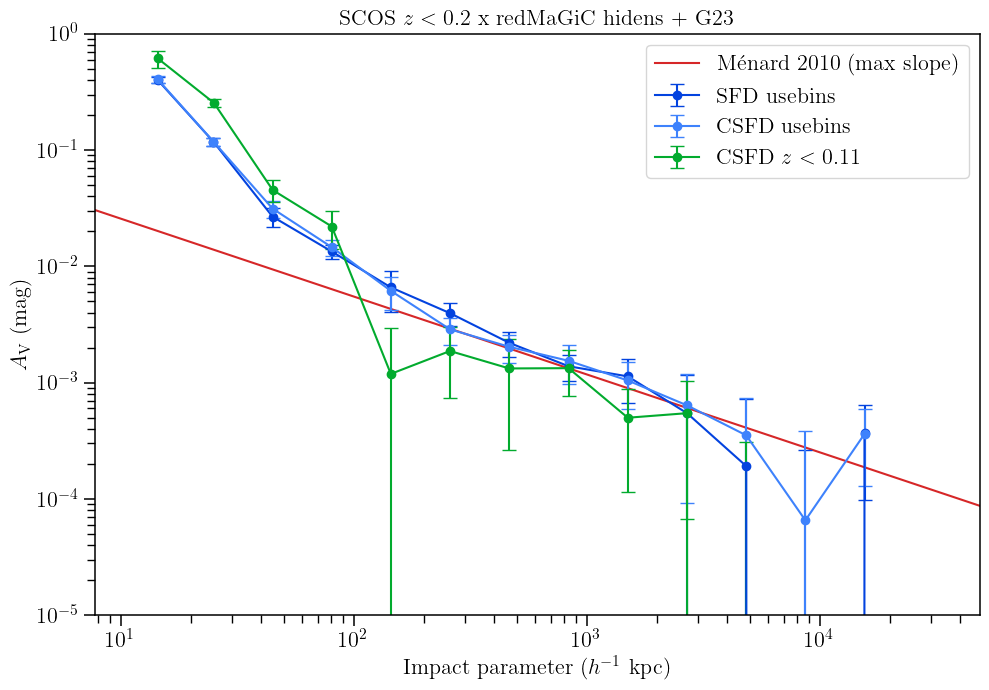

In [9]:
z_fg = 0.13 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# Part 1

# What it says
ax.errorbar(dk_usebins['meanr']*scl, dust_hidens_usebins,
            yerr=dk_usebins['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'SFD usebins')

ax.errorbar(dk_usebins_csfd['meanr']*scl, dust_hidens_usebins_csfd,
            yerr=dk_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'CSFD usebins')
'''
ax.errorbar(dk_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:kelly green', label=r'CSFD 5 zbins')
'''
ax.errorbar(dk_zcut_csfd['meanr']*scl, dust_hidens_zcut_csfd,
            yerr=dk_zcut_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:kelly green', label=r'CSFD $z < 0.11$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'SCOS $z < 0.2$ x redMaGiC hidens + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hidens_comp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: high-lum high-z

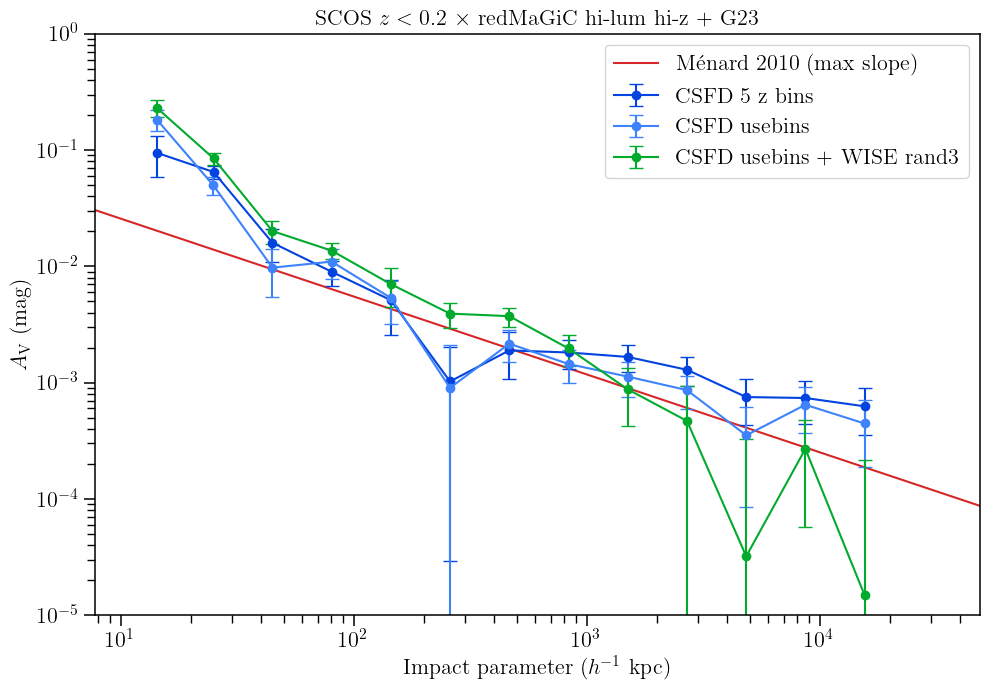

In [30]:
# Set z_theory and z_foreground levels
z_fg = 0.13 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# What it says
ax.errorbar(dk_hiz_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD 5 z bins')

ax.errorbar(dk_hiz_usebins_csfd['meanr']*scl, dust_hiz_usebins_csfd,
            yerr=dk_hiz_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'CSFD usebins')

ax.errorbar(dk_hiz_csfd['meanr']*scl, dust_hiz_rand3_csfd,
            yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
            color='xkcd:kelly green', label=r'CSFD usebins + WISE rand3')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'SCOS $z < 0.2 \ \times $ redMaGiC hi-lum hi-z + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hiz_comp2.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: redMaGiC LRG (`lowz_hidens_fg_x_hiz_bg`)

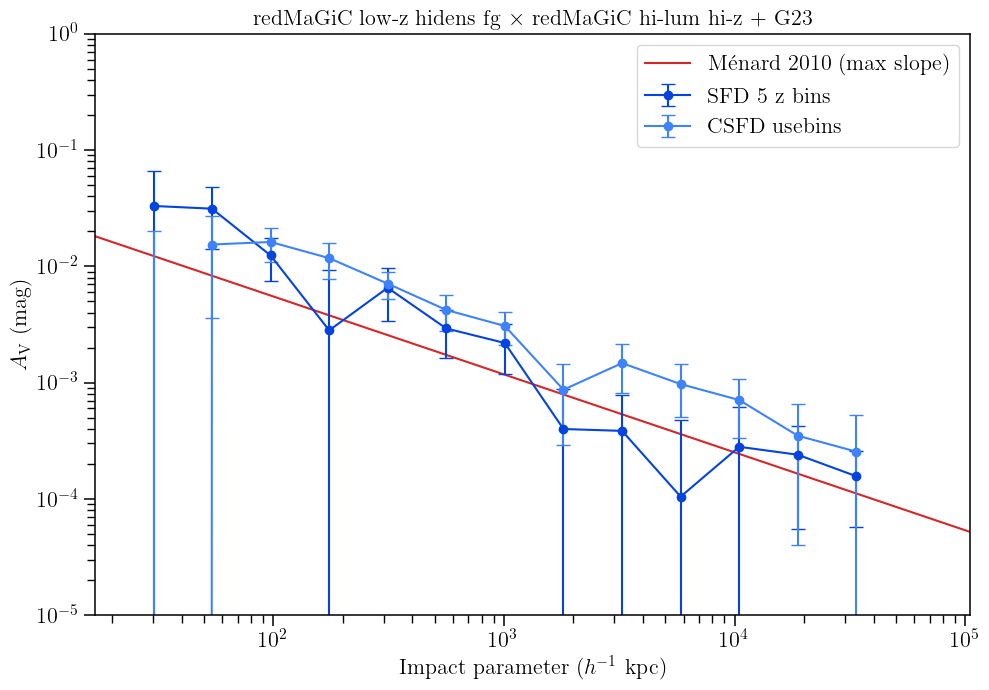

In [11]:
# Set z_theory and z_foreground levels
z_fg = 0.36 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')

ax.errorbar(dk_lrg['meanr']*scl, dust_lrg,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'SFD 5 z bins')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'CSFD usebins')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'redMaGiC low-z hidens fg $\times$ redMaGiC hi-lum hi-z + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_lowz_hidens_fg_x_hiz_bg_csfd_comp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: all CSFD samples

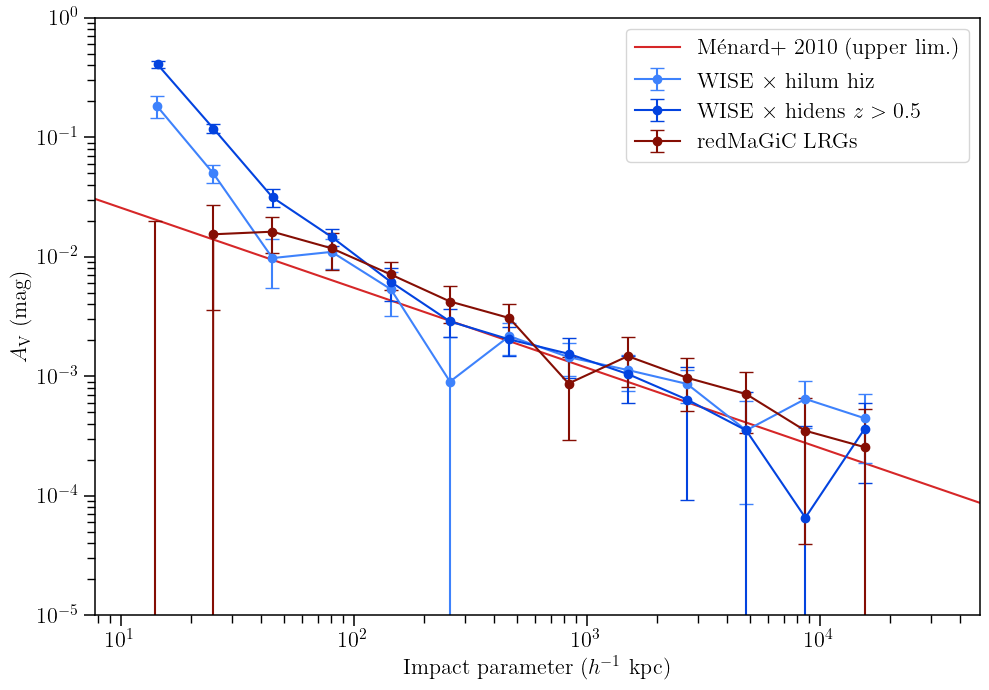

In [12]:
# Set z_theory and z_foreground levels
z_fg = 0.13
z_fg2 = 0.36 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(dk_hiz_usebins_csfd['meanr']*scl, dust_hiz_usebins_csfd,
            yerr=dk_hiz_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz')

ax.errorbar(dk_usebins_csfd['meanr']*scl, dust_hidens_usebins_csfd,
            yerr=dk_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:indian red', label=r'redMaGiC LRGs')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_redmagic_csfd_comp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


# Calculate fits

In [13]:
def do_WLS_fit(this_dk, dust_rel, name=None, start=None, end=None, log=False):
    """
    Perform a weighted least-squares linear regression to
    data, taking care to transform the variables appropriately.

    Inputs
        this_dk: should be the 'compensated' treecorr output
        dust_rel: the corrected A_V relationship (dk-dr+rr)
        name: what are we calling it?
        start: exclude points with index < 'start' for fitting
        end: ibidem, but for points with index > 'end'
        log: if True, fit the relationship in log-space to stabilize the fits.
             Default is False.
    """

    ## Transform the dependent variable (fully compensated kappa)
    if log == True:
        Y = np.log(dust_rel[start:end])        
        ## Also need to transform the weights!
        weights_OG = 1/(this_dk['sigma'][start:end]**2)
        weight_scale = (1/Y)**2
        #weight_scale = (1/(Y+1))**2
        weights = weights_OG * weight_scale
    
    ## Just do regular fit
    else:
        Y = dust_rel[start:end]
        weights = 1/(this_dk['sigma'][start:end]**2)
    
    ## If plotting X on a log-scale, which we are, 
    ## fit relationship on log scale
    X = this_dk['meanlogr'][start:end]

    ## Add intercept to abscissa
    X = sm.add_constant(X)

    ## Do fit
    mod_wls = sm.WLS(Y, X, weights=weights)
    res_wls = mod_wls.fit()

    ## Print results
    print("")
    print(f"Fit result: {name}")
    print("")
    print(res_wls.summary())

    return(res_wls)

In [35]:
res_hiz = do_WLS_fit(
    dk_hiz_rand3_csfd, dust_hiz_rand3_csfd, 
    name='high-lum high-z', start=3, end=10, log=True
)
print(res_hiz.params)
print(f"Fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")

res_hiz_inner = do_WLS_fit(
    dk_hiz_usebins_csfd, dust_hiz_usebins_csfd, 
    name='high-lum high-z inner', start=0, end=4, log=True
)
print(res_hiz_inner.params)
print(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")


Fit result: high-lum high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.961
Model:                            WLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     123.8
Date:                Mon, 12 Aug 2024   Prob (F-statistic):           0.000102
Time:                        22:20:00   Log-Likelihood:                 1.2099
No. Observations:                   7   AIC:                             1.580
Df Residuals:                       5   BIC:                             1.472
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1343 

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [15]:
res_hidens = do_WLS_fit(
    dk_usebins_csfd, dust_hidens_usebins_csfd, 
    name='high-density', start=3, log=True
)
print(res_hidens.params)
print(f"Fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")

res_hidens_inner = do_WLS_fit(
    dk_usebins_csfd, dust_hidens_usebins_csfd, 
    name='high-density inner', start=0, end=4, log=True
)
print(res_hidens_inner.params)
print(f"Fit: {np.exp(res_hidens_inner.params[0]):.2e} * (meanr)^{res_hidens_inner.params[1]:.2f}")


Fit result: high-density

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.688
Model:                            WLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     17.63
Date:                Mon, 12 Aug 2024   Prob (F-statistic):            0.00300
Time:                        10:57:18   Log-Likelihood:                -11.420
No. Observations:                  10   AIC:                             26.84
Df Residuals:                       8   BIC:                             27.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.2371    

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [16]:
res_lrg = do_WLS_fit(
    dk_lrg_usebins_csfd, dust_lrg_usebins_csfd, 
    name='redmagic LRG', start=5, log=True
)
print(res_lrg.params)
print(f"Fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")


Fit result: redmagic LRG

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.891
Model:                            WLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     49.27
Date:                Mon, 12 Aug 2024   Prob (F-statistic):           0.000417
Time:                        10:57:18   Log-Likelihood:                -1.1428
No. Observations:                   8   AIC:                             6.286
Df Residuals:                       6   BIC:                             6.445
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.0262    

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [23]:
linregress_lrg = stats.linregress(
    dk_lrg_usebins_csfd['meanlogr'][5:], 
    np.log(dust_lrg_usebins_csfd[5:])
)
linregress_hiz = stats.linregress(
    dk_hiz_usebins_csfd['meanlogr'][4:], 
    np.log(dust_hiz_usebins_csfd[4:])
)
linregress_hidens = stats.linregress(
    dk_usebins_csfd['meanlogr'][4:], 
    np.log(dust_hidens_usebins_csfd[4:])
)

print("LRG params")
print(linregress_lrg)
print("")

print("high-dens params")
print(linregress_hidens)
print("")

print("high-z params")
print(linregress_hiz)
print("")


print(f"LRG fit: {np.exp(linregress_lrg[1]):.2e} * (meanr)^{linregress_lrg[0]:.2f}")
print(f"High-z fit: {np.exp(linregress_hiz[1]):.2e} * (meanr)^{linregress_hiz[0]:.2f}")
print(f"High-dens fit: {np.exp(linregress_hidens[1]):.2e} * (meanr)^{linregress_hidens[0]:.2f}")

print(f"intercept stderr: {linregress_hidens.intercept_stderr:.2e}")

LRG params
LinregressResult(slope=-0.6416940133255367, intercept=-4.970498283640609, rvalue=-0.9476449233586324, pvalue=0.00034483016602443337, stderr=0.08827566816022137, intercept_stderr=0.2913139686624564)

high-dens params
LinregressResult(slope=-0.7712781797682527, intercept=-4.938407967100719, rvalue=-0.9111844890112393, pvalue=0.0006297070353807691, stderr=0.13181092936731068, intercept_stderr=0.4104637279402624)

high-z params
LinregressResult(slope=-0.429939098451997, intercept=-5.693350688996301, rvalue=-0.8301051079023019, pvalue=0.005612623568207183, stderr=0.10915735728039062, intercept_stderr=0.33991598227594816)

LRG fit: 6.94e-03 * (meanr)^-0.64
High-z fit: 3.37e-03 * (meanr)^-0.43
High-dens fit: 7.17e-03 * (meanr)^-0.77
intercept stderr: 4.10e-01


### Last step: plots with fits :-) 

# Gaia plots, should do those too

In [67]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/gaia_fg/'

dk_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia1 = Table.read(output_path+'dustcorrel_hidens_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_gaia2 = Table.read(output_path+'dustcorrel_hidens_usebins_newrand_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia2 = Table.read(output_path+'dustcorrel_hidens_usebins_newrand_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia2 = Table.read(output_path+'dustcorrel_hidens_usebins_newrand_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia2 = Table.read(output_path+'dustcorrel_hidens_usebins_newrand_fgxbg_randoms.txt', header_start=1, format='ascii')

'''
dk_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia2 = Table.read(output_path+'dustcorrel_hiz_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')
'''
###
### Now define signal 
### 

dust_gaia1 = dk_gaia1['kappa'] - dr_gaia1['kappa'] + rr_gaia1['kappa']
dust_gaia2 = dk_gaia2['kappa'] - dr_gaia2['kappa'] + rr_gaia2['kappa']


## Start with fitting

In [68]:
fit_gaia_hidens = stats.linregress(dk_gaia1['meanlogr'], dust_gaia1)
fit_gaia_hiz = stats.linregress(dk_gaia2['meanlogr'], dust_gaia2)

print("Hidens Gaia\n")
print(fit_gaia_hidens)
print("")

print("Hiz Gaia\n")
print(fit_gaia_hiz)
print("")


print(f"Gaia x high-z fit: {np.exp(fit_gaia_hiz[1]):.2e} * (meanr)^{fit_gaia_hiz[0]:.2f}")
print(f"Gaia x high-dens fit: {np.exp(fit_gaia_hidens[1]):.2e} * (meanr)^{fit_gaia_hidens[0]:.2f}")


Hidens Gaia

LinregressResult(slope=-0.0011781520077311029, intercept=0.0032951056242103267, rvalue=-0.3658697642385709, pvalue=0.21890904924253535, stderr=0.0009035919242216763, intercept_stderr=0.002424347805444239)

Hiz Gaia

LinregressResult(slope=-0.0014399429095915785, intercept=0.0013226460560059703, rvalue=-0.6548996367721825, pvalue=0.01512822724158716, stderr=0.0005009942253448614, intercept_stderr=0.0013441727821658263)

Gaia x high-z fit: 1.00e+00 * (meanr)^-0.00
Gaia x high-dens fit: 1.00e+00 * (meanr)^-0.00


In [69]:
res_gaia2 = do_WLS_fit(dk_gaia2, dust_gaia2, name='Gaia x high-z', log=False)
print(res_gaia2.params)
print(f"Fit: {np.exp(res_gaia2.params[0]):.2e} * (meanr)^{res_gaia2.params[1]:.2f}")


Fit result: Gaia x high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.081
Model:                            WLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.9755
Date:                Tue, 13 Aug 2024   Prob (F-statistic):              0.345
Time:                        20:02:46   Log-Likelihood:                 69.437
No. Observations:                  13   AIC:                            -134.9
Df Residuals:                      11   BIC:                            -133.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0026   

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [70]:
res_gaia1 = do_WLS_fit(dk_gaia1, dust_gaia1, name='Gaia x high-dens', log=False)
print(res_gaia1.params)
print(f"Fit: {np.exp(res_gaia1.params[0]):.2e} * (meanr)^{res_gaia1.params[1]:.2f}")


Fit result: Gaia x high-dens

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.031
Model:                            WLS   Adj. R-squared:                 -0.057
Method:                 Least Squares   F-statistic:                    0.3573
Date:                Tue, 13 Aug 2024   Prob (F-statistic):              0.562
Time:                        20:02:52   Log-Likelihood:                 69.769
No. Observations:                  13   AIC:                            -135.5
Df Residuals:                      11   BIC:                            -134.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


## Plots

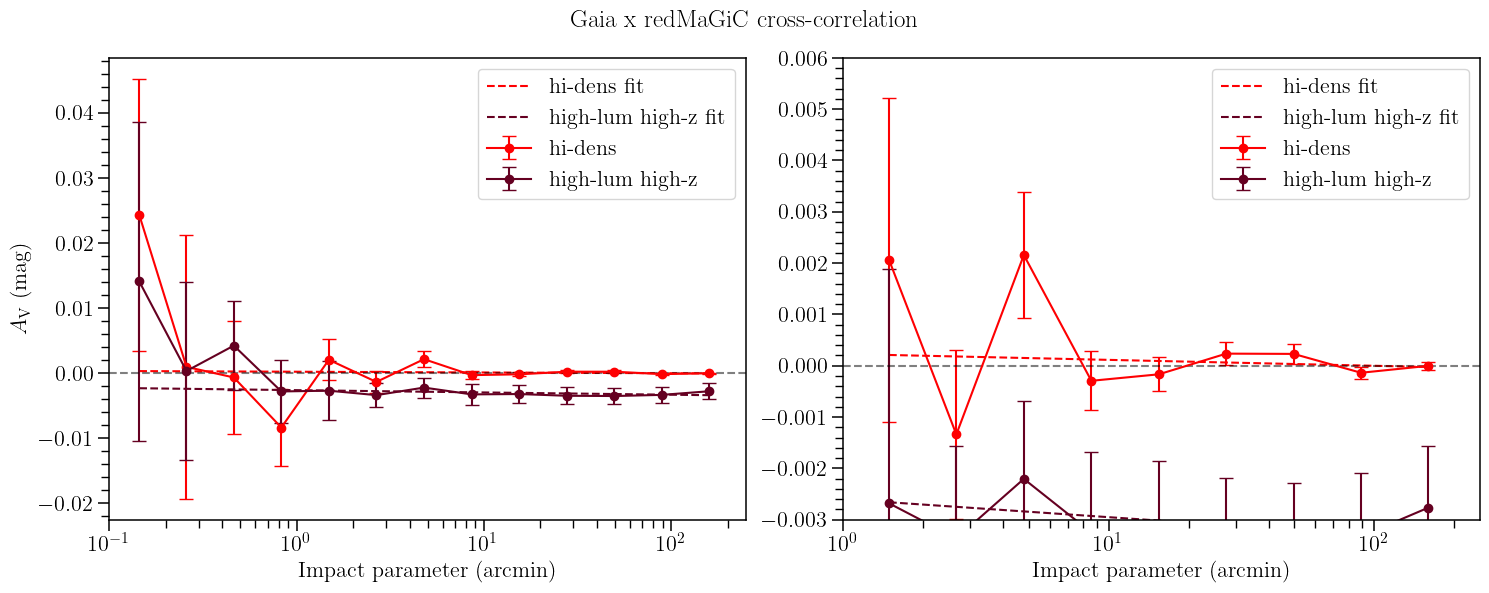

In [71]:
##
## Plot Gaia x redMaGiC results
##

## gaia x high-dens sample
a = res_gaia1.params[1] # Power
b = res_gaia1.params[0] # Coefficient
fit_gaia1 = a * dk_gaia1['meanlogr'] + b

# gaia x high-lum high-z sample
fit_gaia2 = res_gaia2.params[1] * dk_gaia2['meanlogr'] + res_gaia2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_gaia1['meanr'], dust_gaia1,
            yerr=dk_gaia1['sigma'], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[0].plot(dk_gaia1['meanr'], fit_gaia1, ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[0].errorbar(dk_gaia2['meanr'], dust_gaia2,
            yerr=dk_gaia2['sigma'], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[0].plot(dk_gaia1['meanr'], fit_gaia2, ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_gaia1['meanr'][4:], dust_gaia1[4:],
            yerr=dk_gaia1['sigma'][4:], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia1[4:], ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[1].errorbar(dk_gaia2['meanr'][4:], dust_gaia2[4:],
            yerr=dk_gaia2['sigma'][4:], fmt='-o', capsize=5, 
            label=r'high-lum high-z', color='xkcd:maroon')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia2[4:], ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[1].set_xscale('log')
axs[1].set_xlim(1, 250)
axs[1].set_ylim(-3e-3, 6e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('Gaia x redMaGiC cross-correlation', fontsize=18)

figname = 'Gaia_redmagic_crosscorrel_csfd.png'
#fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
#fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )

# DES Star bg plots, should do those too

In [61]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/redmagic_star_bg/'

dk_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_desstar = dk_desstar['kappa'] - dr_desstar['kappa'] + rr_desstar['kappa']


## Start with fitting

In [62]:
fit_desstar = stats.linregress(dk_desstar['meanlogr'], dust_desstar)

print("DES star background \n")
print(fit_desstar)
print("")

print(f"WISExSCOS x DES star fit: {np.exp(fit_desstar[1]):.2e} * (meanr)^{fit_desstar[0]:.2f}")


DES star background 

LinregressResult(slope=0.00023434314395858843, intercept=-0.0009423288511677193, rvalue=0.13687038556939027, pvalue=0.6556860000861247, stderr=0.0005113754852062962, intercept_stderr=0.001372205393234918)

WISExSCOS x DES star fit: 9.99e-01 * (meanr)^0.00


In [63]:
res_desstar = do_WLS_fit(dk_desstar, dust_desstar, name='WISExSCOS x DES star', log=False)
print(res_gaia1.params)
print(f"Fit: {np.exp(res_desstar.params[0]):.2e} * (meanr)^{res_desstar.params[1]:.2f}")


Fit result: WISExSCOS x DES star

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            WLS   Adj. R-squared:                 -0.082
Method:                 Least Squares   F-statistic:                   0.08766
Date:                Tue, 13 Aug 2024   Prob (F-statistic):              0.773
Time:                        18:55:35   Log-Likelihood:                 69.888
No. Observations:                  13   AIC:                            -135.8
Df Residuals:                      11   BIC:                            -134.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


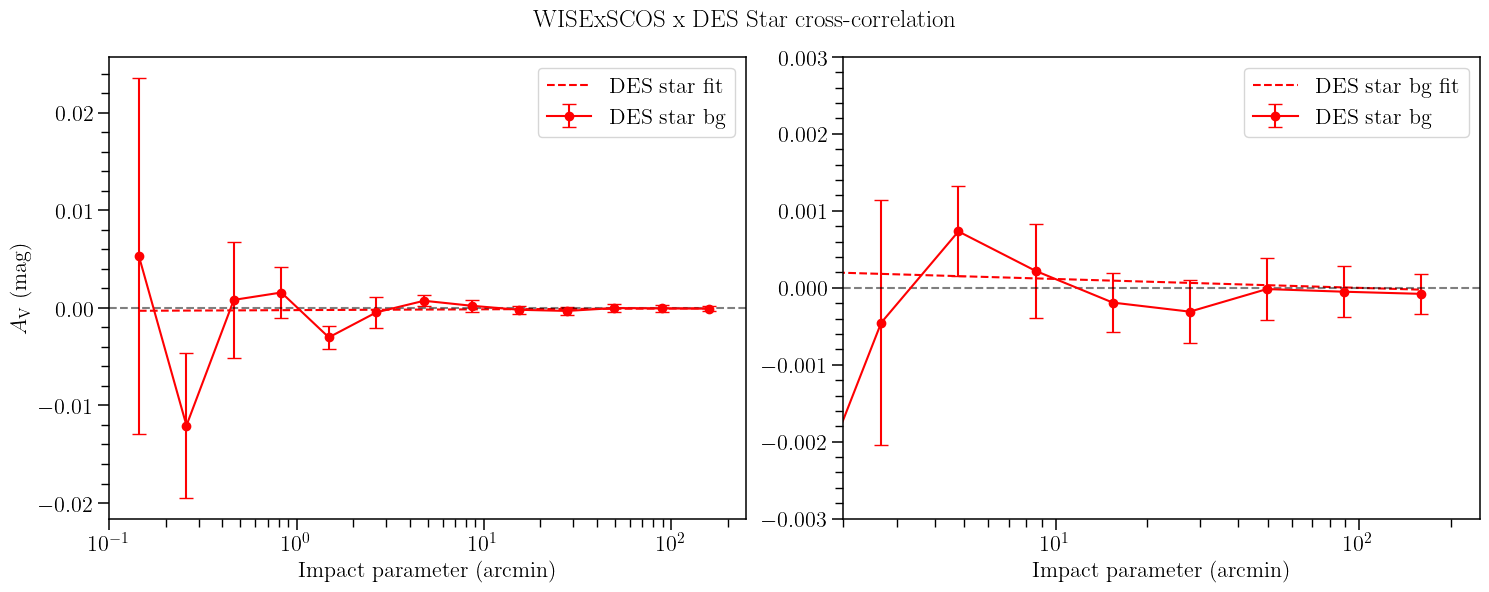

In [66]:
## gaia x high-dens sample
a = res_desstar.params[1] # Power
b = res_desstar.params[0] # Coefficient
fit_desstar = a * dk_desstar['meanlogr'] + b

# gaia x high-lum high-z sample
fit_desstar = res_desstar.params[1] * dk_desstar['meanlogr'] + res_desstar.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_desstar['meanr'], dust_desstar,
            yerr=dk_desstar['sigma'], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[0].plot(dk_desstar['meanr'], fit_desstar, ls='--', color='xkcd:fire engine red', 
        label='DES star fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_desstar['meanr'][4:], dust_desstar[4:],
            yerr=dk_desstar['sigma'][4:], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[1].plot(dk_gaia1['meanr'][4:], fit_gaia1[4:], ls='--', color='xkcd:fire engine red', 
        label='DES star bg fit')


axs[1].set_xscale('log')
axs[1].set_xlim(2, 250)
axs[1].set_ylim(-3e-3, 3e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('WISExSCOS x DES Star cross-correlation', fontsize=18)

figname = 'desstar_crosscorrel_csfd.png'